`In the name of Allah, the Most Gracious, the Most Merciful`

In this project, I used **K-Means Clustering** to group countries based on their economic, health, and demographic features.

First, I explored the dataset and selected the numerical features for clustering. Then, I scaled the features using **StandardScaler** because they have different ranges.

After that, I used the **Elbow Method** and **Silhouette Score** to help choose the number of clusters. Based on the results, I chose **3 clusters** and trained the final K-Means model.

Finally, I analyzed the characteristics of each cluster and used **PCA** to visualize the clusters in 2D.

This project helped me practice the main steps of an **unsupervised learning** problem, from exploring and preparing the data to clustering, interpreting the results, and visualizing the final clusters.


---

In [73]:
import pandas as pd
import matplotlib.pyplot as plt 

In [74]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

In [75]:
data = pd.read_csv("../data/Country-data.csv")
data

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310


---

# understanding the columns 

-  167 rows × 10 columns ---> its shape 

- child_mort ---> mot el adfal

- inflation ---> making food more expensive

- total_fer ---> (Total fertility rate) the average number od childern a woman is expected to have over her lifetime

- gdpp ---> (GDP per capita) gross domestic product per capita 
(ya3ny the country's total economic output (GDP) divided by its population) 

---

In [76]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [77]:
data.isna().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [78]:
data.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


Okay, based on the features and the output of the `info()` method, I decided to drop the country column and use the rest of the features.

In [79]:
data.columns

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')

In [80]:
these_columns = ['child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp']

data[these_columns]

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...
162,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310


---

Since I will use clustering, I need to scale the features before applying the clustering algorithm. The features have different ranges and units, for example, income and gdpp have much larger values than life_expec or inflation.

Because clustering algorithms such as K-Means use distances between data points, features with larger values could have more influence on the results.

Therefore, I will use StandardScaler to put all features on a comparable scale while keeping the information in the dataset.

---

In [81]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data[these_columns])

In [82]:
from sklearn.cluster import KMeans

KMeans_Model = KMeans(n_clusters=5,init='k-means++', random_state=33)

### `n_clusters=5`

This means that I want K-Means to divide the 167 countries into **5 clusters**.

I started with random number then I will use:

* **Elbow Method**
* **Silhouette Score**

to find a suitable number of clusters.

### `init='k-means++'`

This determines how K-Means chooses the **initial centroids**.

`k-means++` chooses the initial centroids in a smarter way than random initialization, which helps K-Means start with better positions.


----

In [83]:
cluster = KMeans_Model.fit_predict(data_scaled)

---

### `fit()` vs `fit_predict()`

Here I need to understand the difference between `fit()` and `fit_predict()` because I was a little confused about them.

When I use:

```python
KMeans_Model.fit(data_scaled)
```

I am basically telling the model to **learn the clusters** from my data. It calculates the cluster centers (centroids) and stores them inside the model.

After that, I can get the cluster centers using:

```python
KMeans_Model.cluster_centers_
```

And I can also get the cluster labels using:

```python
KMeans_Model.labels_
```

But when I use:

```python
cluster = KMeans_Model.fit_predict(data_scaled)
```

I am doing both things at once:

* `fit` → the model learns the cluster centers
* `predict` → the model assigns each country to its closest cluster

The important thing is that `fit_predict()` **returns the cluster labels directly**, so I can save them in `cluster`.

So basically, this:

```python
cluster = KMeans_Model.fit_predict(data_scaled)
```

is almost the same as:

```python
KMeans_Model.fit(data_scaled)
cluster = KMeans_Model.labels_
```

For my project, I will use `fit_predict()` because I need the cluster labels to add them to my original dataset.


---

In [84]:
cluster.shape

(167,)

In [85]:
data['cluster'] = cluster

In [86]:
pd.DataFrame(KMeans_Model.cluster_centers_,columns = these_columns ,index= ['ClusterA','ClusterB','ClusterC','ClusterD','ClusterE'])

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
ClusterA,-0.828609,0.172621,0.859190,-0.296373,1.462275,-0.478189,1.107649,-0.763681,1.661902
ClusterB,-0.495794,0.285142,0.020170,0.533397,-0.226394,-0.366747,0.244768,-0.496304,-0.311425
ClusterC,1.431317,-0.481812,-0.164652,-0.167858,-0.721863,0.389040,-1.306885,1.417711,-0.621447
ClusterD,-0.849003,4.935673,-0.008163,4.548058,2.439542,-0.504206,1.226824,-1.038863,2.440797
ClusterE,-0.244439,-0.393988,-0.544325,-0.726964,-0.199990,0.515134,0.204876,-0.265330,-0.361635


In [87]:
len(KMeans_Model.labels_)

167

--- To7fa ---

In [88]:
pd.Series(KMeans_Model.labels_).value_counts()

# To see how many countries are in each cluster

1    54
2    44
4    36
0    30
3     3
Name: count, dtype: int64

Evaluation Time 

In [89]:
KMeans_Model.inertia_
# Inertia tells us how close the points are to the centroid of their assigned cluster

632.031757971584

In [90]:
from tqdm import tqdm
# to add a progress bar to a loop

In [91]:
InertiaDict = {} # to save the inertia for each number of clusters {i : inertia}

for i in tqdm(range(2, 16)): # ya3ny for each value of i, you create a new K-Means model

    KMeansModel = KMeans(
        n_clusters=i, # starting from 2 to 15
        init='k-means++', 
        random_state=33
    )

    KMeansModel.fit(data_scaled) 

    InertiaDict[i] = KMeansModel.inertia_

100%|██████████| 14/14 [00:00<00:00, 250.44it/s]


In [92]:
InertiaDict

{2: 1050.2145582853307,
 3: 831.5351582151586,
 4: 700.7057359845705,
 5: 632.031757971584,
 6: 588.8145042615552,
 7: 541.3767533129705,
 8: 459.60407147885013,
 9: 445.58177792686746,
 10: 420.91512733116036,
 11: 385.50529407013056,
 12: 365.80874625119264,
 13: 351.45491373665976,
 14: 327.55825560881027,
 15: 314.89547021289354}

Now, I am gonna to make a graph to see the elbow method and determine the best number of clusters

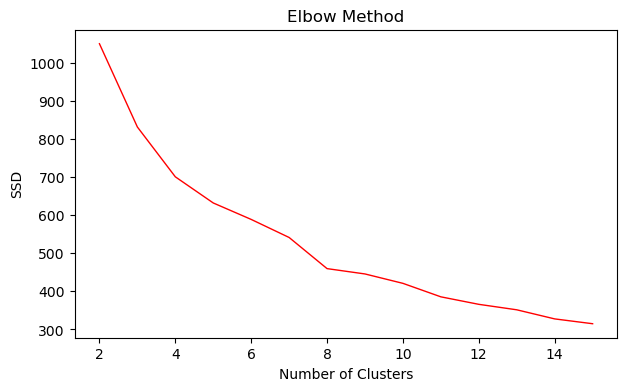

In [ ]:
plt.figure(figsize = (7, 4))
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('SSD') # SSD is essentially the within-cluster sum of squared distances, which is what KMeansModel.inertia_ represents.

XGraph = InertiaDict.keys()
yGraph = InertiaDict.values()

plt.plot(XGraph,yGraph,linewidth=1,color= 'r', 
         alpha=1,linestyle = 'solid') 

plt.savefig('../images/Elbow Method for Different Numbers of Clusters.png', dpi=300, bbox_inches='tight')

plt.show()

I think number of cluster = 6 or 7 or 8 is good

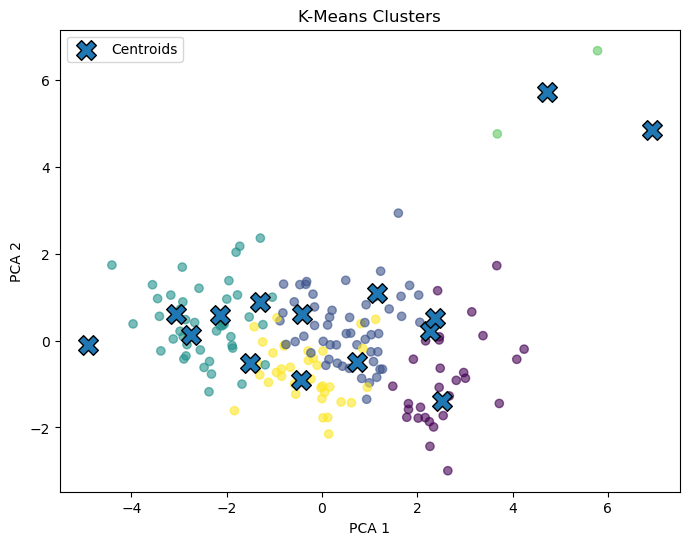

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(data_scaled)

centers_pca = pca.transform(KMeansModel.cluster_centers_)

plt.figure(figsize=(8, 6))

# Countries
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cluster,
    alpha=0.6
)

# Centroids
plt.scatter(
    centers_pca[:, 0],
    centers_pca[:, 1],
    marker='X',
    s=200,
    edgecolor='black',
    label='Centroids'
)

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('K-Means Clusters')
plt.legend()

plt.savefig('../images/kmeans_clusters_pca 1.png', dpi=300, bbox_inches='tight')

plt.show()

the graph is messy

In [95]:
from sklearn.metrics import silhouette_score

silhouette_scores = {}

for k in range(2, 16):
    model = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=33
    )
    
    labels = model.fit_predict(data_scaled)
    silhouette_scores[k] = silhouette_score(data_scaled, labels)

`Silhouette Score graph` is answering:

“For each possible number of clusters, how good is the separation between my clusters?”

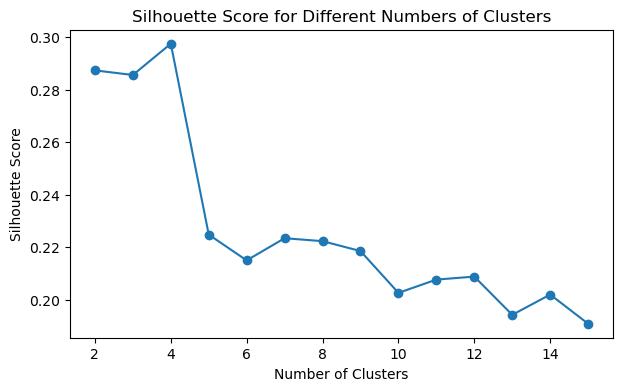

In [111]:
plt.figure(figsize=(7, 4))

plt.plot(
    silhouette_scores.keys(),
    silhouette_scores.values(),
    marker='o'
)

plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different Numbers of Clusters')

plt.savefig('../images/Silhouette Score for Different Numbers of Clusters.png', dpi=300, bbox_inches='tight')

plt.show()

Higher silhouette scores generally indicate better-separated and more cohesive clusters

in graph = 4

In [97]:
KMeansModel = KMeans(
    n_clusters=4,
    init='k-means++',
    random_state=33
)

cluster = KMeansModel.fit_predict(data_scaled)

data['cluster'] = cluster

In [98]:
data['cluster'].value_counts()

cluster
1    87
2    45
0    32
3     3
Name: count, dtype: int64

In [99]:
pd.Series(KMeansModel.labels_).value_counts()

1    87
2    45
0    32
3     3
Name: count, dtype: int64

In [100]:
pd.DataFrame(
    KMeansModel.cluster_centers_,
    columns=these_columns,
    index=[f'Cluster {i}' for i in range(4)]
)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster 0,-0.822941,0.183308,0.829894,-0.261252,1.398378,-0.499856,1.074331,-0.768250,1.595436
Cluster 1,-0.399187,-0.000922,-0.207778,0.037486,-0.232345,-0.005132,0.233418,-0.407227,-0.354047
Cluster 2,1.413564,-0.457615,-0.187898,-0.189897,-0.707839,0.398989,-1.297031,1.402874,-0.612761
Cluster 3,-0.849003,4.935673,-0.008163,4.548058,2.439542,-0.504206,1.226824,-1.038863,2.440797


In [101]:
from sklearn.metrics import silhouette_score

silhouette_score(data_scaled, cluster)

np.float64(0.2975089381471821)

In [102]:
silhouette_scores = {}

for k in range(2, 16):
    model = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=33
    )
    
    labels = model.fit_predict(data_scaled)
    
    silhouette_scores[k] = silhouette_score(data_scaled, labels)

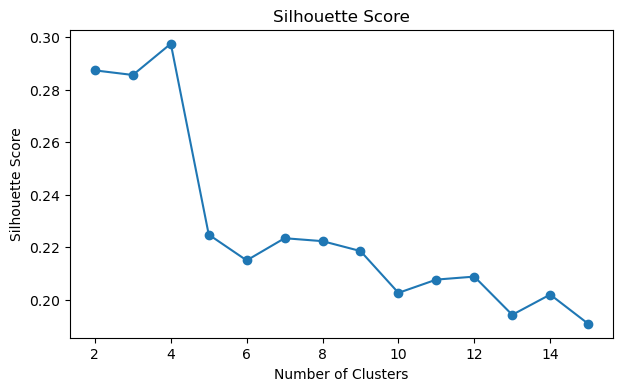

In [103]:
plt.figure(figsize=(7, 4))

plt.plot(
    silhouette_scores.keys(),
    silhouette_scores.values(),
    marker='o'
)

plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')

plt.show()

let's try 3 

In [104]:
KMeansModel = KMeans(
    n_clusters=3,
    init='k-means++',
    random_state=33
)

cluster = KMeansModel.fit_predict(data_scaled)

data['cluster'] = cluster

In [105]:
data['cluster'].value_counts()

cluster
1    86
2    45
0    36
Name: count, dtype: int64

In [106]:
data.groupby('cluster')[these_columns].mean()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
cluster,,,,,,,,,
0,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
1,22.456977,40.273128,6.251047,47.362394,12321.744186,7.720884,72.566279,2.340349,6461.767442
2,95.106667,28.602444,6.301111,42.306667,3539.844444,11.986778,59.055556,5.065333,1766.711111


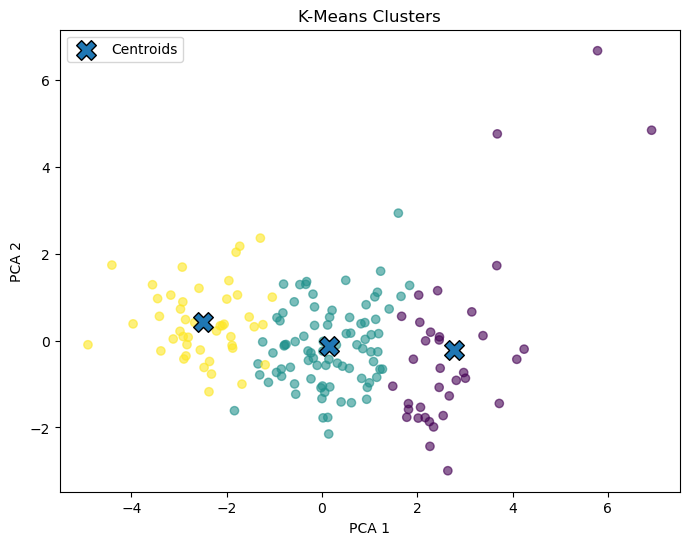

In [ ]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(data_scaled)

centers_pca = pca.transform(KMeansModel.cluster_centers_)

plt.figure(figsize=(8, 6))

# Countries
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cluster,
    alpha=0.6
)

# Centroids
plt.scatter(
    centers_pca[:, 0],
    centers_pca[:, 1],
    marker='X',
    s=200,
    edgecolor='black',
    label='Centroids'
)

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('K-Means Clusters')
plt.legend()

plt.savefig('../images/kmeans_clusters_pca2.png', dpi=300, bbox_inches='tight')

plt.show()

By looking at this graph, I think that 3 is the best number of clusters because the data points appear to be reasonably separated into three groups.


In [109]:
data.groupby('cluster')[these_columns].mean()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
cluster,,,,,,,,,
0,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
1,22.456977,40.273128,6.251047,47.362394,12321.744186,7.720884,72.566279,2.340349,6461.767442
2,95.106667,28.602444,6.301111,42.306667,3539.844444,11.986778,59.055556,5.065333,1766.711111


---

**By comparing the average values of the features:**

Cluster 0: Higher income and GDPP, lower child mortality and fertility, and higher life expectancy.

Cluster 1: Moderate economic and health conditions.

Cluster 2: Lower income and GDPP, higher child mortality and fertility, and lower life expectancy.

This helped me understand the main characteristics of each cluster.

---

In [ ]:
data[['country', 'cluster']].sort_values('cluster')
# to see which countries belong to eaach cluster

,country,cluster
7,Australia,0
15,Belgium,0
11,Bahrain,0
8,Austria,0
29,Canada,0
...,...,...
149,Timor-Leste,2
150,Togo,2
132,Sierra Leone,2
165,Yemen,2


---

### Final Conclusion

Using K-Means clustering, I grouped the countries into 3 clusters based on their economic, health, and demographic features.

The clusters showed clear differences in income, GDPP, child mortality, life expectancy, and fertility rate. PCA was also used to visualize the clusters in 2D.

This project helped me understand how unsupervised learning can be used to discover patterns and group similar countries without using predefined labels.
